#**Introduction to PyTorch**
* Open source deep learning framework used to build,train and deploy AI systems.

* Very beginner friendly.

* PyTorch code looks very similar to normal Python code.

* More flexible.

#**Tensors**
*Core data structure in PyTorch

*Very similiar in structure with numpy arrays.

*It differ from other structures in :
   
   1. They are optimized for fast math operations.

   2. It support GPU acceleration.


*Perform basic operations like arithmetic, matrix multiplication.

*Can perform linear algebra operations like determinant, statistical operations.

In [ ]:
import torch
import numpy as np

a=torch.tensor([3,4,5])
b=np.array([3,4,5])
print(a)
print(b)

tensor([3, 4, 5])
[3 4 5]


In [ ]:
apple=torch.tensor([5])  # 0D tensor
print(apple)

tensor([5])


In [ ]:
list_of_items=torch.tensor([4,5,6])    #1D tensor
print(list_of_items)

tensor([4, 5, 6])


In [ ]:
items_in_trays=torch.tensor([[2,3,4],      # 2D tensor
                              [6,7,8]])
print(items_in_trays)

tensor([[2, 3, 4],
        [6, 7, 8]])


**Addition of two tensors**

In [ ]:
frst_tray=torch.tensor([2,3,4])
scnd_tray=torch.tensor([6,7,8,])
print(frst_tray)
print(scnd_tray)

tensor([2, 3, 4])
tensor([6, 7, 8])


In [ ]:
frst_tray+scnd_tray

tensor([ 8, 10, 12])

In [ ]:
a=torch.tensor([1,2,3])
b=torch.tensor([[5,6],
                [10,11]])
print(a)
print(b)

tensor([1, 2, 3])
tensor([[ 5,  6],
        [10, 11]])


In [ ]:
a+b

RuntimeError: The size of tensor a (3) must match the size of tensor b (2) at non-singleton dimension 1

In [ ]:
a.shape

torch.Size([3])

In [ ]:
b.shape

torch.Size([2, 2])

$$
\begin{bmatrix}
1 & 2 & 3
\end{bmatrix}
+
\begin{bmatrix}
5 & 6  \\
10 & 11
\end{bmatrix}
=
\text{Undefined}
$$

Here is a very simple PyTorch example that compares CPU and GPU speed using tensor addition.

In [ ]:
import time

# Create large tensors
size = 100000000

# ---------------- CPU ----------------
a = torch.ones(size)
b = torch.ones(size)

start = time.time()  ## Records the starting time before computation

c = a + b

cpu_time = time.time() - start  ## Calculates how much time the operation took

print("CPU Time:", cpu_time)

CPU Time: 0.2312612533569336


In [ ]:
if torch.cuda.is_available():  ## Check whether a CUDA GPU is available

    device = torch.device("cuda")     # Select the GPU device

    a= a.to(device)  ## Move tensor 'a' from CPU memory to GPU memory
    b = b.to(device)

    torch.cuda.synchronize()    # Wait until all previous GPU operations are completed

    start = time.time()

    c = a + b

    torch.cuda.synchronize()  # Wait until  GPU operations are completed

    gpu_time = time.time() - start

    print("GPU Time:", gpu_time)

else:
    print("GPU not available")

GPU Time: 0.05585312843322754


**Representing tensors as real world data**

A tensor stores structured real-world information.

| Subject | Marks |
| ------- | ----- |
| Math    | 98    |
| Science | 76    |
| English | 88    |

In [ ]:
a=torch.tensor([98,76,88])
print(a)

tensor([98, 76, 88])


It represents student data.

**Images as tensors**

Image is fundamentally just a collection of numerical pixel values.

For a grayscale image, each pixel stores a single intensity value, typically from 0 (black) to 255 (white). These values can be arranged in a 2D tensor

\begin{bmatrix}
0 & 255 & 120  \\
34 & 80 & 200 \\
90 & 60 & 10
\end{bmatrix}
=

In [ ]:
a=torch.tensor([[0,255,120],[34,80,200],[90,60,10]])
print(a)

tensor([[  0, 255, 120],
        [ 34,  80, 200],
        [ 90,  60,  10]])


**Class probabilities**

| Class | Probability |
| ----- | ----------- |
| Cat   | 20%         |
| Dog   | 70%         |


In [ ]:
a=torch.tensor([0.2, 0.7])
print(a)

tensor([0.2000, 0.7000])


These numbers means :
| Value | Meaning                 |
| ----- | ----------------------- |
| 0.2   | 20% confidence for Cat  |
| 0.7   | 70% confidence for Dog  |

**Conversion of Tensor to Image**

In [ ]:
import matplotlib.pyplot as plt  #Python library used for visualisation

# Step 1: Create a 2D tensor
image = torch.rand(5, 5)

print("Tensor Values:\n")
print(image)

print("\nShape:", image.shape)

Tensor Values:

tensor([[0.4289, 0.7992, 0.5887, 0.6031, 0.4178],
        [0.1053, 0.7974, 0.5456, 0.6356, 0.4184],
        [0.7051, 0.3184, 0.4118, 0.1315, 0.1542],
        [0.8924, 0.6703, 0.9647, 0.7251, 0.4727],
        [0.8918, 0.0247, 0.8353, 0.6876, 0.9626]])

Shape: torch.Size([5, 5])


In [ ]:
# Step 2: Convert tensor values (0 to 1)
# into pixel range (0 to 255)

pixel_image = (image * 255).int()

print("\nPixel Values (0-255):\n")
print(pixel_image)


Pixel Values (0-255):

tensor([[109, 203, 150, 153, 106],
        [ 26, 203, 139, 162, 106],
        [179,  81, 105,  33,  39],
        [227, 170, 246, 184, 120],
        [227,   6, 212, 175, 245]], dtype=torch.int32)


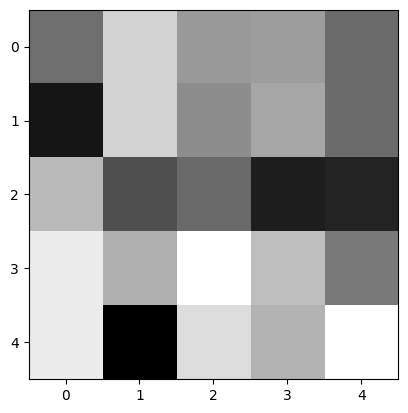

In [ ]:
# Step 3: Display tensor as grayscale image

plt.imshow(image, cmap='gray')
plt.show()